<a href="https://colab.research.google.com/github/Aryan-yadav7/ML_learning/blob/main/Loan%20approval%20decision%20tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("07_loan_approval.csv")

print(df.head())
print(df.shape)

  ApplicantID  Age  AnnualIncome  LoanAmount  CreditScore  EmploymentYears  \
0       L0001   25         35200       30000          703              7.4   
1       L0002   55         38300      133000          712              2.1   
2       L0003   50         35800       95000          678             10.9   
3       L0004   40         43000      103000          694              5.2   
4       L0005   40         77800       84000          728              3.4   

      Education MaritalStatus PropertyArea SelfEmployed LoanApproved  
0      Graduate       Married        Rural           No            Y  
1      Graduate       Married        Urban           No            N  
2      Graduate       Married    Semiurban          Yes            Y  
3      Graduate       Married    Semiurban           No            N  
4  Not Graduate      Divorced        Urban           No            N  
(600, 11)


In [3]:
print(df.info())
print(df.isnull().sum())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ApplicantID      600 non-null    object 
 1   Age              600 non-null    int64  
 2   AnnualIncome     600 non-null    int64  
 3   LoanAmount       600 non-null    int64  
 4   CreditScore      600 non-null    int64  
 5   EmploymentYears  600 non-null    float64
 6   Education        600 non-null    object 
 7   MaritalStatus    600 non-null    object 
 8   PropertyArea     600 non-null    object 
 9   SelfEmployed     600 non-null    object 
 10  LoanApproved     600 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 51.7+ KB
None
ApplicantID        0
Age                0
AnnualIncome       0
LoanAmount         0
CreditScore        0
EmploymentYears    0
Education          0
MaritalStatus      0
PropertyArea       0
SelfEmployed       0
LoanApproved       

In [4]:
X = df.drop(columns=["ApplicantID", "LoanApproved"])
y = df["LoanApproved"]

In [5]:
print(X.head())
print(y.head())

   Age  AnnualIncome  LoanAmount  CreditScore  EmploymentYears     Education  \
0   25         35200       30000          703              7.4      Graduate   
1   55         38300      133000          712              2.1      Graduate   
2   50         35800       95000          678             10.9      Graduate   
3   40         43000      103000          694              5.2      Graduate   
4   40         77800       84000          728              3.4  Not Graduate   

  MaritalStatus PropertyArea SelfEmployed  
0       Married        Rural           No  
1       Married        Urban           No  
2       Married    Semiurban          Yes  
3       Married    Semiurban           No  
4      Divorced        Urban           No  
0    Y
1    N
2    Y
3    N
4    N
Name: LoanApproved, dtype: object


In [6]:
categorical_columns = [
    "Education",
    "MaritalStatus",
    "PropertyArea",
    "SelfEmployed"
]

numerical_columns = [
    "Age",
    "AnnualIncome",
    "LoanAmount",
    "CreditScore",
    "EmploymentYears"
]

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [8]:
X_encoded = preprocessor.fit_transform(X)

print(X_encoded.shape)

(600, 15)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (480, 15)
Testing data: (120, 15)


In [11]:
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

In [12]:
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [13]:
y_pred = model.predict(X_test)

print(y_pred)

['N' 'N' 'N' 'Y' 'N' 'N' 'N' 'Y' 'Y' 'N' 'N' 'N' 'Y' 'N' 'Y' 'N' 'Y' 'N'
 'N' 'Y' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'N' 'N' 'Y' 'N'
 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'N' 'N' 'Y' 'Y' 'N' 'N' 'N' 'Y' 'Y' 'Y' 'N' 'N'
 'N' 'N' 'N' 'Y' 'Y' 'N' 'N' 'N' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'N' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'N' 'Y' 'N' 'N' 'Y' 'Y'
 'Y' 'N' 'N' 'N' 'N' 'N' 'Y' 'Y' 'Y' 'N' 'N' 'N' 'N' 'Y' 'Y' 'Y' 'N' 'Y'
 'N' 'Y' 'N' 'Y' 'N' 'N' 'N' 'Y' 'N' 'N' 'Y' 'N']


In [14]:
#Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.6833333333333333
Accuracy (%): 68.33333333333333


In [15]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[46 21]
 [17 36]]


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           N       0.73      0.69      0.71        67
           Y       0.63      0.68      0.65        53

    accuracy                           0.68       120
   macro avg       0.68      0.68      0.68       120
weighted avg       0.69      0.68      0.68       120



In [17]:
importance = model.feature_importances_

print(importance)

[0.         0.         0.         0.         0.         0.02875363
 0.         0.         0.         0.         0.         0.0634176
 0.31660058 0.59122819 0.        ]


In [18]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                        Feature  Importance
13       remainder__CreditScore    0.591228
12        remainder__LoanAmount    0.316601
11      remainder__AnnualIncome    0.063418
5       cat__PropertyArea_Rural    0.028754
2   cat__MaritalStatus_Divorced    0.000000
1   cat__Education_Not Graduate    0.000000
0       cat__Education_Graduate    0.000000
6   cat__PropertyArea_Semiurban    0.000000
4     cat__MaritalStatus_Single    0.000000
3    cat__MaritalStatus_Married    0.000000
7       cat__PropertyArea_Urban    0.000000
10               remainder__Age    0.000000
9         cat__SelfEmployed_Yes    0.000000
8          cat__SelfEmployed_No    0.000000
14   remainder__EmploymentYears    0.000000


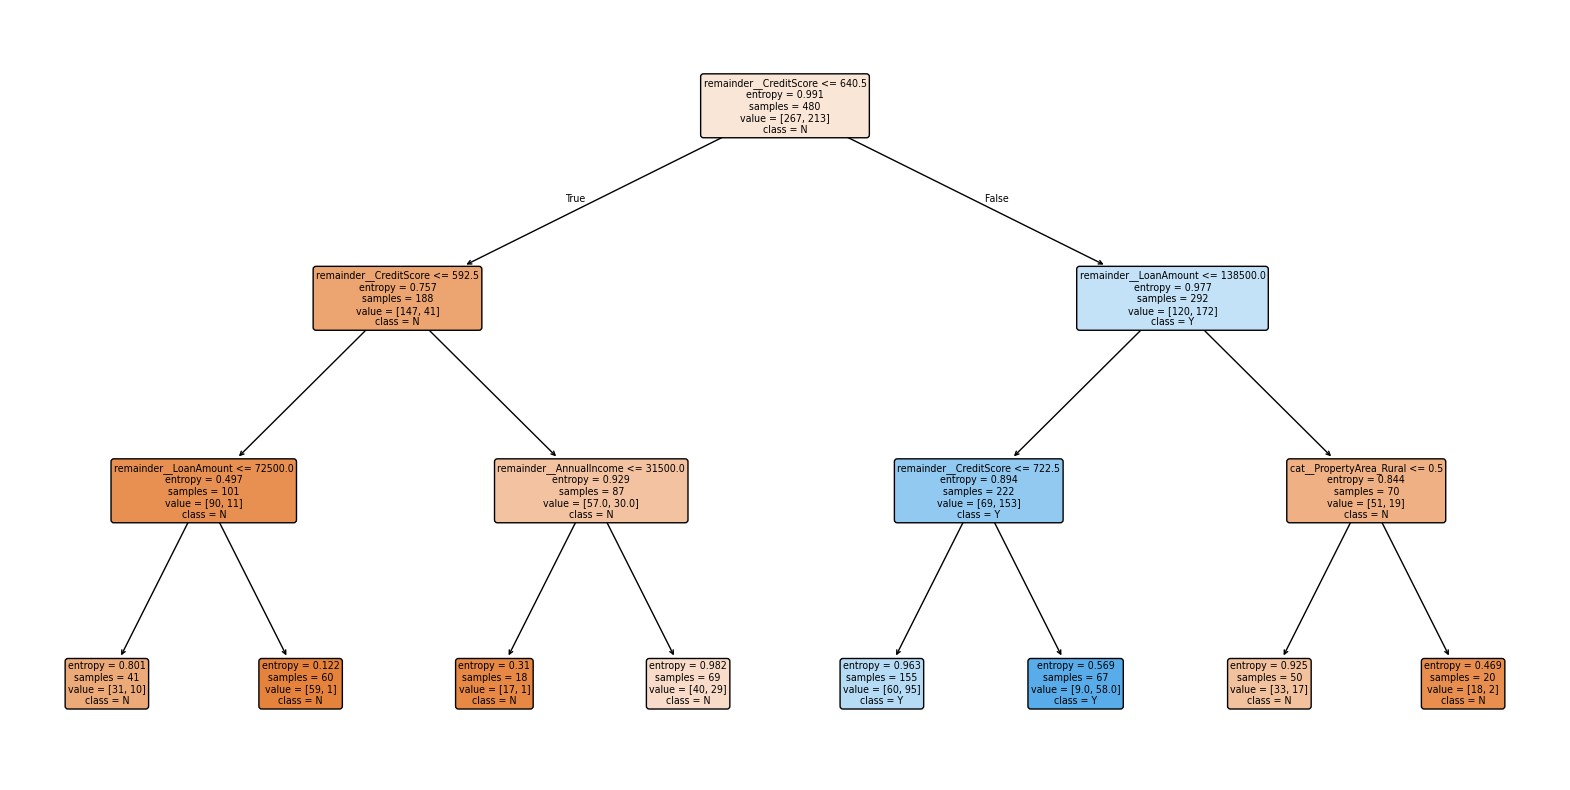

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=feature_names,
    class_names=model.classes_,
    filled=True,
    rounded=True
)

plt.show()